In [ ]:
import torch
import torch.nn as nn
import numpy as np

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Solving 1D viscous burger's equation

$$u_t + u u_x - \nu u_{xx} = 0$$

In [ ]:
class PINN(nn.Module):
  def __init__(self,
               input_size:int,
               hidden_units:int,
               output_size: int):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_size, hidden_units),
        nn.Tanh(),
        nn.Linear(hidden_units, hidden_units),
        nn.Tanh(),
        nn.Linear(hidden_units, output_size),
        nn.Tanh(),
    )

  def forward(self, t, x):
    inputs = torch.cat([x,t],dim=1)
    return self.net(inputs)

In [ ]:
model = PINN(input_size=2,
             hidden_units=50,
             output_size=1).to(device)

Domain: $x \in [-1, 1]$, $t \in [0, 1]$

Initial Condition:
$u(x, 0) = -\sin(\pi x)$

In [ ]:
# define viscosity
nu = 0.01/np.pi
nu

0.003183098861837907

In [ ]:
# x_ic = uniform points btwn -1,1 and t_ic is all zeroes in order to acquire points for through initial conditions

N_ic = 100
x_ic = torch.linspace(-1,1,N_ic).view(-1,1).to(device)
t_ic = torch.zeros_like(x_ic)

print(f"shape of x: {x_ic.shape} \nshape of t: {t_ic.shape}")

shape of x: torch.Size([100, 1]) 
shape of t: torch.Size([100, 1])


 $u(x, 0) = -\sin(\pi x)$

In [ ]:
u_ic = -torch.sin(np.pi*x_ic)

Boundary Conditions (Dirichlet):

$u(-1, t) = 0$
$u(1, t) = 0$

In [ ]:
N_bc = 100
t_bc = torch.linspace(0,1,N_bc).view(-1,1).to(device)
x_bc_negone = -torch.ones_like(t_bc)
x_bc_posone = torch.ones_like(t_bc)

u_bc = torch.zeros_like(t_bc)

In [ ]:
## we are randomly choosing the collocation points as of now(rather chebyshev nodes)
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)


N_f = 10000
t_f = torch.rand(N_f,1).to(device)
x_f = -1+2*torch.rand(N_f,1) #as torch.rand() returns random numbers between [0,1) we multiplied it by 2 and added -1

In [ ]:
# enable auto_grad
t_f.requires_grad = True
x_f.requires_grad = True

In [ ]:
x_f, t_f = x_f.to(device), t_f.to(device)

In [ ]:
u = model(x_f,t_f)

$$u_t(t,x) = \frac{\partial u_{\theta}(t,x)}{\partial t}$$

In [ ]:
u_t = torch.autograd.grad(
    u, t_f,
    grad_outputs= torch.ones_like(u),
    create_graph=True
)[0]

$$u_x(t,x) = \frac{\partial u_{\theta}(t,x)}{\partial x}$$

In [ ]:
u_x = torch.autograd.grad(
    u, x_f,
    grad_outputs= torch.ones_like(u),
    create_graph=True
)[0]

$$u_{xx}(t,x) = \frac{\partial^2 u_{\theta}(t,x)}{\partial x^2}$$

In [ ]:
u_xx = torch.autograd.grad(
    u_x, x_f,
    grad_outputs= torch.ones_like(u_x),
    create_graph=True
)[0]

$$f(t_f, x_f) = u_t(t_f, x_f) + u(t_f, x_f)u_x(t_f, x_f) - \nu u_{xx}(t_f, x_f)$$

In [ ]:
f = u_t + u * u_x + - nu * u_xx

At collocation points:

We do NOT know the true value of $u$

We do NOT compare against labels

We only enforce:

$f(t,x) \approx 0$

$$Physics Loss$$
$$MSE_f = \frac{1}{N_f} \sum_{i=1}^{N_f} |f(t_i, x_i)|^2$$

In [ ]:
loss_f = torch.mean(f*2)

$$MSE_{ic} = \frac{1}{N_{ic}} \sum_{i} |u_{\theta}(0,x_i) - u_{ic,i}|^2$$

In [ ]:
u_pred_ic = model(t_ic, x_ic)
loss_ic = torch.mean((u_pred_ic-u_ic)**2)

$$u(t,−1)=0,u(t,1)=0$$

$$MSE_{bc} = \frac{1}{N_{bc}} \sum |u_{\theta}(t,-1)|^2 + \frac{1}{N_{bc}} \sum |u_{\theta}(t,1)|^2$$

In [ ]:
u_pred_pos = model(t_bc, x_bc_posone)
u_pred_neg = model(t_bc, x_bc_negone)

loss_bc = torch.mean(u_pred_pos**2) + torch.mean(u_pred_neg**2)

In [ ]:
#total loss
loss = loss_f+loss_ic+loss_bc

In [ ]:
## lets use adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [ ]:
from tqdm import tqdm

epochs = 20000
for epoch in tqdm(range(epochs)):
  u = model(t_f, x_f)
  u_t = torch.autograd.grad(
        u, t_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
  )[0]

  u_x = torch.autograd.grad(
      u, x_f,
      grad_outputs=torch.ones_like(u),
      create_graph=True
  )[0]

  u_xx = torch.autograd.grad(
      u_x, x_f,
      grad_outputs=torch.ones_like(u_x),
      create_graph=True
  )[0]

  f = u_t + u * u_x - nu * u_xx
  loss_f = torch.mean(f**2)

  u_pred_ic = model(t_ic, x_ic)
  loss_ic = torch.mean((u_pred_ic - u_ic)**2)

  u_pred_neg = model(t_bc, x_bc_negone)
  u_pred_pos = model(t_bc, x_bc_posone)
  loss_bc = torch.mean(u_pred_neg**2) + torch.mean(u_pred_pos**2)

  loss = loss_f + loss_ic + loss_bc

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch%1000==0:
    print(f"Epoch: {epoch} | Loss: {loss.item():.8f} | IC : {loss_ic.item():.8f} | Physics Loss: {loss_f:.8f} | BC : {loss_bc:.8f}")




  0%|          | 0/20000 [00:00<?, ?it/s]

Epoch: 0 | Loss: 0.70833194 | IC : 0.52220780 | Physics Loss: 0.04938666 | BC : 0.13673744


  5%|▌         | 1016/20000 [00:08<02:26, 129.42it/s]

Epoch: 1000 | Loss: 0.09337156 | IC : 0.05611267 | Physics Loss: 0.03699008 | BC : 0.00026880


 10%|█         | 2015/20000 [00:16<02:16, 131.87it/s]

...

 90%|█████████ | 18017/20000 [02:25<00:15, 131.40it/s]

Epoch: 18000 | Loss: 0.01714402 | IC : 0.00637641 | Physics Loss: 0.01069853 | BC : 0.00006908


 95%|█████████▌| 19014/20000 [02:32<00:07, 131.04it/s]

Epoch: 19000 | Loss: 0.01640741 | IC : 0.00618628 | Physics Loss: 0.01016192 | BC : 0.00005921


100%|██████████| 20000/20000 [02:41<00:00, 124.17it/s]


## Evaluation and Plotting

In [ ]:
# Evaluation grid
x_eval = torch.linspace(-1, 1, 256).view(-1, 1).to(device)
t_eval = torch.linspace(0, 1, 100).view(-1, 1).to(device)

# Create meshgrid
T, X = torch.meshgrid(
    t_eval.squeeze(),
    x_eval.squeeze(),
    indexing='ij'
)

# Flatten for model input
t_flat = T.reshape(-1, 1)
x_flat = X.reshape(-1, 1)

In [ ]:
with torch.no_grad():
    u_pred = model(t_flat, x_flat)

In [ ]:
U = u_pred.reshape(100, 256).cpu().numpy()
X_np = X.cpu().numpy()
T_np = T.cpu().numpy()

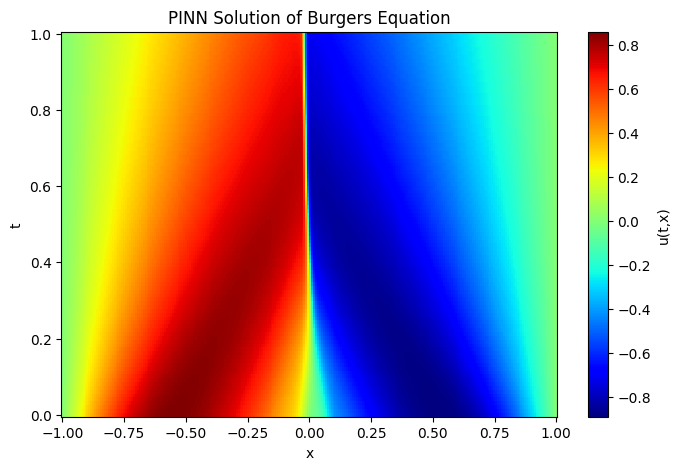

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.pcolormesh(X_np, T_np, U, shading='auto', cmap='jet')
plt.colorbar(label='u(t,x)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN Solution of Burgers Equation')
plt.show()

## Plot Solution Snapshots

In [ ]:
time_indices = [0, 25, 50, 75, 99]  # t = 0, 0.25, 0.5, 0.75, 1.0

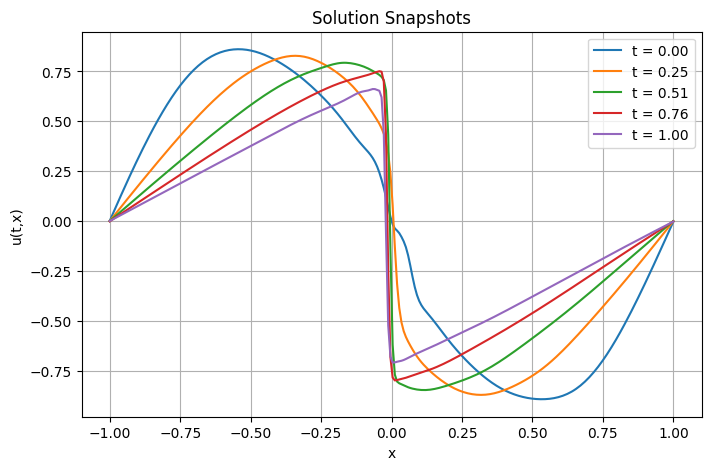

In [ ]:
plt.figure(figsize=(8, 5))

for idx in time_indices:
    plt.plot(
        x_eval.cpu().numpy(),
        U[idx, :],
        label=f"t = {T_np[idx,0]:.2f}"
    )

plt.xlabel('x')
plt.ylabel('u(t,x)')
plt.title('Solution Snapshots')
plt.legend()
plt.grid(True)
plt.show()

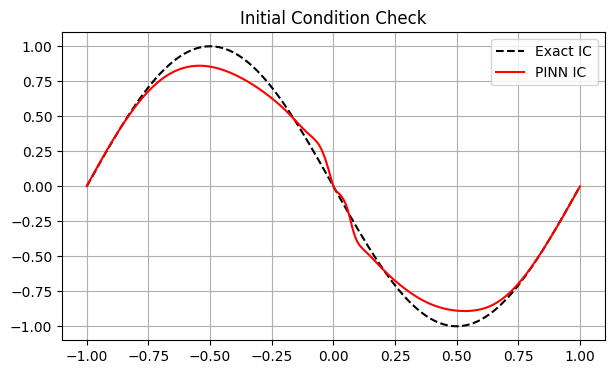

In [ ]:
u_ic_pred = U[0, :]
u_ic_true = -np.sin(np.pi * x_eval.cpu().numpy())

plt.figure(figsize=(7,4))
plt.plot(x_eval.cpu().numpy(), u_ic_true, 'k--', label='Exact IC')
plt.plot(x_eval.cpu().numpy(), u_ic_pred, 'r', label='PINN IC')
plt.legend()
plt.title('Initial Condition Check')
plt.grid(True)
plt.show()

In [ ]:
t_flat.requires_grad = True
x_flat.requires_grad = True

u = model(t_flat, x_flat)

u_t = torch.autograd.grad(u, t_flat, torch.ones_like(u), create_graph=True)[0]
u_x = torch.autograd.grad(u, x_flat, torch.ones_like(u), create_graph=True)[0]
u_xx = torch.autograd.grad(u_x, x_flat, torch.ones_like(u_x), create_graph=True)[0]

f = u_t + u * u_x - nu * u_xx
F = f.reshape(100, 256).detach().cpu().numpy()


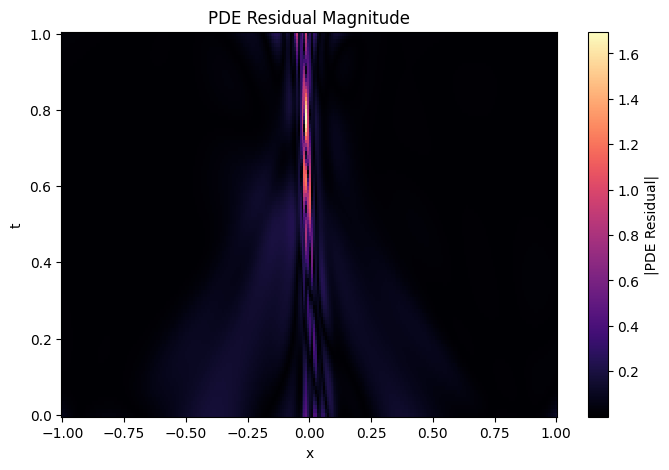

In [ ]:
plt.figure(figsize=(8,5))
plt.pcolormesh(X_np, T_np, np.abs(F), shading='auto', cmap='magma')
plt.colorbar(label='|PDE Residual|')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PDE Residual Magnitude')
plt.show()